In [1]:
import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
import time

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':0.5,
                 'steps':100, 
                 'dkmax':50,
                 'epsrel':10**(-5),
                 'alpha':0.05,
                 'omega_cutoff':2.0*np.pi*5.0,                 
                 'temp':0.0}


opt_parameters = {'x0': pt_parameters['omega_cutoff'],
                'z0': 0.0,
                'lbx':2.0*np.pi*0.0,
                'ubx':2.0*np.pi*10.0,
                'lbz':0.0,
                'ubz':0.0,
                'initial_state':'mixed',
                'target_state':'x-'}


omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

initial_state = op.spin_dm('mixed')
target_state = op.spin_dm('x-')
target_derivative = target_state.T

t_list = np.linspace(0,t_max,num_steps+1)


In [2]:
import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
import numpy as np
import matplotlib.pyplot as plt

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=dkmax)
#pt=oqupy.pt_tempo_compute(
#    bath=bath,
#    start_time=0.0,
#    end_time=t_max,
#   parameters=parameters)
pt=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_tebd = pt.get_process_tensor()

building influence functional: 100%|██████████| 50/50 [00:00<00:00, 1321.67it/s]

rank  7 (7, 4, 7)


In [3]:
print(process_tensor_tebd._first_mpo_tensor.shape)
print(process_tensor_tebd._mpo_tensor.shape)
mpo_list=[]
from oqupy.system_dynamics import _get_pt_mpos, _get_pt_mpos_backprop

first_mpo=_get_pt_mpos([process_tensor_tebd],0)
mpo_list.append(first_mpo)



new_mpo=_get_pt_mpos_backprop(mpo_list,0)
print(new_mpo[0].shape)

(1, 7, 4, 4)
(7, 7, 4, 4)
(7, 1, 4, 4)


--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:03
Elapsed time: 3.4s


array([[ 0.49905066+4.21754711e-15j, -0.28936997-3.06103532e-14j],
       [-0.28936997-4.45795095e-14j,  0.49905066-3.80121054e-15j]])

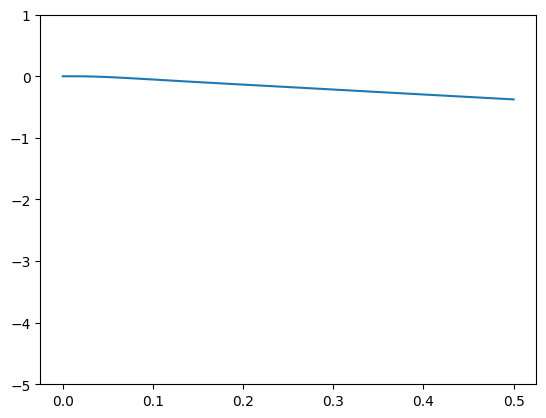

In [4]:
def hamiltonian_t(t):
    return pt_parameters['omega_cutoff']*op.sigma('x')/2 + 0.0*op.sigma('z')/2

system = oqupy.TimeDependentSystem(hamiltonian_t)

Rho_0=oqupy.operators.spin_dm('mixed')

dynamics = oqupy.compute_dynamics(
       process_tensor=process_tensor_tebd,        
       system=system,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps)

t, s_x = dynamics.expectations(op.sigma('x'), real=True)

plt.plot(t,np.log10(np.array(s_x)+1),label='sx')
plt.ylim((-5.0,1.0))

dynamics.states[-1]


In [5]:
from oqupy.system_dynamics import _get_caps
_get_caps([process_tensor_tebd],2)


[array([-7.33186468e-01+6.80027649e-01j, -1.66533454e-15-1.66533454e-16j,
         6.66133815e-16-8.04911693e-16j, -2.22044605e-16-3.60822483e-16j,
        -3.60822483e-16-3.88578059e-16j, -1.24900090e-16+1.11022302e-16j,
        -1.14827277e-08+1.06501861e-08j])]

In [6]:
from oqupy.gate_gradient import compute_dynamical_map,compute_gradient_and_map
def discrete_hamiltonian(hx,hz):
    return hx*op.sigma('x')/2 + hz*op.sigma('z')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

h_z = np.ones(2*num_steps)*0 
h_x = np.ones(2*num_steps)*omega_cutoff

parameters = np.vstack((h_x,h_z)).T
parameters.shape

map=compute_dynamical_map(system,
        [process_tensor_tebd],
        parameters,
        dt,
        start_time=0,
        num_steps=num_steps)

grad=compute_gradient_and_map(system,
        [process_tensor_tebd],
        parameters,
        start_time=0,
        dt=dt,
        num_steps=num_steps)

(7, 4, 4)
(7, 4, 4)
--> Compute backward propagation:


ValueError: Cannot connect edges of unequal dimension. Dimension of edge '__unnamed_edge__': 4, Dimension of edge '__unnamed_edge__': 7.

  0.0%    0 of  100 [----------------------------------------] 00:00:01

In [ ]:
map.shape

(4, 4)

In [ ]:
vec_Rho=Rho_0.flatten('C')

In [ ]:
final_Rho=vec_Rho@map

In [ ]:
print(final_Rho)

print(dynamics.states[-1])

[ 0.49904967+1.05485379e-16j -0.28927741-3.08988946e-14j
 -0.28927741-4.46170878e-14j  0.49904967+8.97187716e-16j]
[[ 0.49905066-4.22666454e-16j -0.28936997-3.10226996e-14j]
 [-0.28936997-4.41949187e-14j  0.49905066+1.08880318e-15j]]
